# Data merge and feature engineering


## I. Importing essential libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
from pathlib import Path
import json

import folium
from folium.plugins import TimeSliderChoropleth
import requests
import branca.colormap as cm
from scipy.stats import gaussian_kde
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

## II. Impoting datasets and creating base dataframes

In [2]:
data_dir = Path("../data")
weather_file = data_dir / "weather_processed.csv"
alarms_file = data_dir / "war_events_processed.csv"
isw_file = data_dir / "isw_processed_svd.csv"
tg_file = data_dir / "telegram_processed_svd.csv"

output = "final_merged_dataset.parquet"

In [3]:
df_weather = pd.read_csv(weather_file)
df_war_events = pd.read_csv(alarms_file)
df_isw_matrix = pd.read_csv(isw_file)
df_tg_matrix = pd.read_csv(tg_file)

## III. Data merge

### Weather (main) and War_events merge

In [4]:
df_weather.shape

(817972, 41)

In [5]:
df_war_events.shape

(924664, 5)

In [6]:
df_weather.head()

,datetime_hour,region_id,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,...,hour_conditions_simple_Cloudy,hour_conditions_simple_Rain,hour_conditions_simple_Snow,day_of_week,hour,city_name,day_datetime,day_sunrise,day_sunset,region_key
0,2022-02-24 00:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.300,100.0,4.17,...,True,False,False,3,0,Vinnytsia,2022-02-24,06:58:49,17:40:52,Вінницька
1,2022-02-24 00:00:00,3,4.9,0.7,2.6,0.0,83.7,0.118,100.0,4.17,...,True,False,False,3,0,Lutsk,2022-02-24,07:13:36,17:51:06,Волинська
2,2022-02-24 00:00:00,4,8.0,-2.0,3.1,-2.2,70.6,0.000,0.0,0.00,...,False,False,False,3,0,Dnipro,2022-02-24,06:31:28,17:15:39,Дніпропетровська
3,2022-02-24 00:00:00,6,5.5,1.5,3.3,0.2,80.8,0.800,100.0,4.17,...,True,False,False,3,0,Zhytomyr,2022-02-24,06:59:29,17:38:29,Житомирська
4,2022-02-24 00:00:00,7,6.7,-2.4,1.8,-1.6,79.9,0.000,0.0,0.00,...,True,False,False,3,0,Uzhgorod,2022-02-24,07:22:33,18:06:25,Закарпатська


In [7]:
df_war_events.head()

,datetime_hour,region_id,region_key,alarm_minutes_in_hour,alarm_active
0,2022-02-24 00:00:00,1,АР Крим,0.0,0
1,2022-02-24 00:00:00,2,Вінницька,0.0,0
2,2022-02-24 00:00:00,3,Волинська,0.0,0
3,2022-02-24 00:00:00,4,Дніпропетровська,0.0,0
4,2022-02-24 00:00:00,5,Донецька,0.0,0


In [8]:
df_weather['datetime_hour'] = pd.to_datetime(df_weather['datetime_hour'], errors="coerce")
df_war_events['datetime_hour'] = pd.to_datetime(df_war_events['datetime_hour'], errors="coerce")

In [9]:
df_final = pd.merge(df_weather, df_war_events[['datetime_hour', 'region_id', 'alarm_active', 'alarm_minutes_in_hour']], on=['datetime_hour', 'region_id'], how='left')

In [10]:
df_final.shape

(817972, 43)

In [11]:
print(f"Main dataset rows before merge: {df_weather.shape[0]} \nMain datased rows after merge: {df_final.shape[0]} \n{'Merge correct' if df_weather.shape[0]==df_final.shape[0] else 'Merge incorrect'}")

Main dataset rows before merge: 817972 
Main datased rows after merge: 817972 
Merge correct


In [12]:
df_final['region_key'].unique()

<ArrowStringArray>
[        'Вінницька',         'Волинська',  'Дніпропетровська',
       'Житомирська',      'Закарпатська',        'Запорізька',
 'Івано-Франківська',          'Київська',    'Кіровоградська',
         'Львівська',      'Миколаївська',           'Одеська',
        'Полтавська',        'Рівненська',           'Сумська',
     'Тернопільська',        'Харківська',        'Херсонська',
       'Хмельницька',         'Черкаська',       'Чернівецька',
      'Чернігівська',              'Київ']
Length: 23, dtype: str

#### We have 844417 rows, just as in main weather dataset, due to the lack of data on occupied territory - Crimea and Luhansk. 

In [13]:
df_final = df_final.sort_values(['region_id', 'datetime_hour'])
df_final.head()

,datetime_hour,region_id,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,...,hour_conditions_simple_Snow,day_of_week,hour,city_name,day_datetime,day_sunrise,day_sunset,region_key,alarm_active,alarm_minutes_in_hour
0,2022-02-24 00:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,False,3,0,Vinnytsia,2022-02-24,06:58:49,17:40:52,Вінницька,0,0.0
23,2022-02-24 01:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,False,3,1,Vinnytsia,2022-02-24,06:58:49,17:40:52,Вінницька,0,0.0
46,2022-02-24 02:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,False,3,2,Vinnytsia,2022-02-24,06:58:49,17:40:52,Вінницька,0,0.0
69,2022-02-24 03:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,False,3,3,Vinnytsia,2022-02-24,06:58:49,17:40:52,Вінницька,0,0.0
92,2022-02-24 04:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,False,3,4,Vinnytsia,2022-02-24,06:58:49,17:40:52,Вінницька,0,0.0


In [14]:
df_final.info()

<class 'pandas.DataFrame'>
Index: 817972 entries, 0 to 817971
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   datetime_hour                  817972 non-null  datetime64[us]
 1   region_id                      817972 non-null  int64         
 2   day_tempmax                    817972 non-null  float64       
 3   day_tempmin                    817972 non-null  float64       
 4   day_temp                       817972 non-null  float64       
 5   day_dew                        817972 non-null  float64       
 6   day_humidity                   817972 non-null  float64       
 7   day_precip                     817972 non-null  float64       
 8   day_precipprob                 817972 non-null  float64       
 9   day_precipcover                817972 non-null  float64       
 10  day_snow                       817972 non-null  float64       
 11  day_windgust    

### ISW Merge

In [15]:
df_isw_matrix.shape

(1469, 151)

In [16]:
df_isw_matrix.head()

,date,isw_topic_0,isw_topic_1,isw_topic_2,isw_topic_3,isw_topic_4,isw_topic_5,isw_topic_6,isw_topic_7,isw_topic_8,...,isw_topic_140,isw_topic_141,isw_topic_142,isw_topic_143,isw_topic_144,isw_topic_145,isw_topic_146,isw_topic_147,isw_topic_148,isw_topic_149
0,2022-02-24,0.674152,-0.095414,0.067509,0.121319,0.074836,-0.033696,0.005578,0.019746,-0.029529,...,0.047305,-0.002384,0.013211,0.048349,0.006209,-0.041097,0.000087,0.015538,0.025757,-0.003631
1,2022-02-25,0.645147,-0.072253,0.237083,0.058186,0.104955,-0.046603,0.014071,0.010018,-0.003788,...,0.025987,-0.026661,0.030789,0.027636,-0.004228,-0.057144,-0.004171,-0.003163,-0.007573,-0.006642
2,2022-02-26,0.656422,-0.083477,0.261790,0.086386,0.116005,-0.046837,0.013271,0.010132,-0.006695,...,-0.002390,-0.039834,0.020151,-0.001614,-0.002251,-0.036544,-0.001048,0.029518,-0.007903,0.010710
3,2022-02-27,0.689292,-0.069547,0.258504,0.080406,0.115551,-0.040608,0.010869,0.011264,-0.002490,...,0.003456,-0.018278,0.024068,-0.013224,-0.009262,-0.020008,0.016880,0.005487,-0.010509,0.022649
4,2022-02-28,0.658799,-0.081240,0.215800,0.121471,0.123017,-0.041490,0.035385,0.017471,-0.008623,...,0.008283,-0.000317,-0.000986,-0.011936,-0.020725,-0.010608,0.014215,0.023448,0.001904,0.018182


In [17]:
df_final.head()

,datetime_hour,region_id,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,...,hour_conditions_simple_Snow,day_of_week,hour,city_name,day_datetime,day_sunrise,day_sunset,region_key,alarm_active,alarm_minutes_in_hour
0,2022-02-24 00:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,False,3,0,Vinnytsia,2022-02-24,06:58:49,17:40:52,Вінницька,0,0.0
23,2022-02-24 01:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,False,3,1,Vinnytsia,2022-02-24,06:58:49,17:40:52,Вінницька,0,0.0
46,2022-02-24 02:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,False,3,2,Vinnytsia,2022-02-24,06:58:49,17:40:52,Вінницька,0,0.0
69,2022-02-24 03:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,False,3,3,Vinnytsia,2022-02-24,06:58:49,17:40:52,Вінницька,0,0.0
92,2022-02-24 04:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,False,3,4,Vinnytsia,2022-02-24,06:58:49,17:40:52,Вінницька,0,0.0


In [18]:
df_isw_matrix = df_isw_matrix.rename(columns={'date': 'day_datetime'})

In [19]:
df_final['day_datetime'] = pd.to_datetime(df_final['day_datetime']).dt.date
df_isw_matrix['day_datetime'] = pd.to_datetime(df_isw_matrix['day_datetime']).dt.date

In [20]:
df_isw_matrix.isna().sum()

day_datetime     0
isw_topic_0      0
isw_topic_1      0
isw_topic_2      0
isw_topic_3      0
                ..
isw_topic_145    0
isw_topic_146    0
isw_topic_147    0
isw_topic_148    0
isw_topic_149    0
Length: 151, dtype: int64

In [21]:
df_isw_matrix = df_isw_matrix.fillna(0)

In [22]:
rows_before = df_final.shape[0]

In [23]:
df_final = df_final.merge(df_isw_matrix, on="day_datetime", how="left")

In [24]:
rows_after = df_final.shape[0]

In [25]:
print(f"Before: {rows_before} rows.\nAfter: {rows_after} rows.\n{'Merge correct' if rows_before == rows_after else 'Merge incorrect'}")

Before: 817972 rows.
After: 817972 rows.
Merge correct


In [26]:
df_final.head(15)

,datetime_hour,region_id,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,...,isw_topic_140,isw_topic_141,isw_topic_142,isw_topic_143,isw_topic_144,isw_topic_145,isw_topic_146,isw_topic_147,isw_topic_148,isw_topic_149
0,2022-02-24 00:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.047305,-0.002384,0.013211,0.048349,0.006209,-0.041097,0.000087,0.015538,0.025757,-0.003631
1,2022-02-24 01:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.047305,-0.002384,0.013211,0.048349,0.006209,-0.041097,0.000087,0.015538,0.025757,-0.003631
2,2022-02-24 02:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.047305,-0.002384,0.013211,0.048349,0.006209,-0.041097,0.000087,0.015538,0.025757,-0.003631
3,2022-02-24 03:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.047305,-0.002384,0.013211,0.048349,0.006209,-0.041097,0.000087,0.015538,0.025757,-0.003631
4,2022-02-24 04:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.047305,-0.002384,0.013211,0.048349,0.006209,-0.041097,0.000087,0.015538,0.025757,-0.003631
5,2022-02-24 05:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.047305,-0.002384,0.013211,0.048349,0.006209,-0.041097,0.000087,0.015538,0.025757,-0.003631
6,2022-02-24 06:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.047305,-0.002384,0.013211,0.048349,0.006209,-0.041097,0.000087,0.015538,0.025757,-0.003631
7,2022-02-24 07:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.047305,-0.002384,0.013211,0.048349,0.006209,-0.041097,0.000087,0.015538,0.025757,-0.003631
8,2022-02-24 08:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.047305,-0.002384,0.013211,0.048349,0.006209,-0.041097,0.000087,0.015538,0.025757,-0.003631
9,2022-02-24 09:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.047305,-0.002384,0.013211,0.048349,0.006209,-0.041097,0.000087,0.015538,0.025757,-0.003631


In [27]:
df_final.shape

(817972, 193)

In [28]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 817972 entries, 0 to 817971
Columns: 193 entries, datetime_hour to isw_topic_149
dtypes: bool(4), datetime64[us](1), float64(179), int64(4), object(1), str(4)
memory usage: 1.2+ GB


### Telegram Merge

In [29]:
df_tg_matrix.shape

(130418, 252)

In [30]:
df_tg_matrix.head()

,date,channel,tg_topic_0,tg_topic_1,tg_topic_2,tg_topic_3,tg_topic_4,tg_topic_5,tg_topic_6,tg_topic_7,...,tg_topic_240,tg_topic_241,tg_topic_242,tg_topic_243,tg_topic_244,tg_topic_245,tg_topic_246,tg_topic_247,tg_topic_248,tg_topic_249
0,2026-03-17 01:31:21,kpszsu,0.138465,-0.060347,0.284671,0.035601,0.116456,-0.045463,-0.021404,0.031473,...,0.032808,0.093800,-0.069880,0.004953,-0.050572,0.002973,0.033703,-0.030074,-0.039642,0.065714
1,2026-03-17 01:21:32,kpszsu,0.081445,-0.029977,0.247861,0.054075,0.095709,-0.057322,-0.032291,-0.002144,...,0.022844,0.061741,-0.099778,-0.040678,-0.017302,0.050442,-0.032312,-0.019222,0.001714,-0.011180
2,2026-03-17 00:45:16,kpszsu,0.105084,-0.046298,0.205981,0.022232,0.084708,-0.026968,-0.018273,0.035228,...,-0.006270,-0.004745,-0.021264,-0.040773,0.023039,0.027518,-0.034993,0.000479,0.020928,-0.028859
3,2026-03-17 00:33:10,kpszsu,0.157535,-0.071472,0.326986,0.093080,0.102398,-0.106918,-0.002767,0.013840,...,-0.002598,0.002334,-0.003293,-0.005758,0.003161,0.003687,-0.003392,-0.015742,0.024436,0.006963
4,2026-03-16 23:30:39,kpszsu,0.086284,-0.013447,0.206107,0.011940,0.060368,-0.059965,-0.001821,0.019170,...,0.000333,0.018163,-0.014486,0.006608,-0.000406,0.008269,0.006597,-0.000130,0.009959,0.008867


In [31]:
df_tg_matrix.tail(5)

,date,channel,tg_topic_0,tg_topic_1,tg_topic_2,tg_topic_3,tg_topic_4,tg_topic_5,tg_topic_6,tg_topic_7,...,tg_topic_240,tg_topic_241,tg_topic_242,tg_topic_243,tg_topic_244,tg_topic_245,tg_topic_246,tg_topic_247,tg_topic_248,tg_topic_249
130413,2022-02-25 09:45:10,kpszsu,0.020260,0.003010,0.019604,-0.004270,-0.017974,0.042540,-0.001457,0.009154,...,0.027771,0.011515,0.030133,0.006338,-0.007921,0.002182,0.009057,-0.025187,-0.000008,0.004170
130414,2022-02-25 09:43:53,kpszsu,0.036856,-0.017407,0.025895,0.005321,-0.041815,0.076052,-0.054188,0.138157,...,0.015877,0.010110,0.036470,-0.015028,-0.006703,0.047245,0.009053,-0.006635,-0.021697,-0.023936
130415,2022-02-25 00:43:47,kpszsu,0.025424,-0.008920,0.037626,0.004519,-0.031715,0.075999,-0.046593,0.148629,...,-0.002928,0.014550,0.020617,-0.005018,-0.016592,0.018170,0.012201,-0.006091,-0.014534,-0.011366
130416,2022-02-25 00:43:23,kpszsu,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
130417,2022-02-24 23:17:22,kpszsu,0.010204,0.001464,0.024673,0.001217,-0.015579,0.039516,-0.024036,0.093166,...,0.010781,0.009812,0.062213,-0.022939,-0.013145,0.059785,0.038512,0.020110,-0.001856,0.013671


In [32]:
df_tg_matrix['datetime_hour'] = pd.to_datetime(df_tg_matrix['date']).dt.floor('h')

C:\Users\Uw11\AppData\Local\Temp\ipykernel_8844\1220961098.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_tg_matrix['datetime_hour'] = pd.to_datetime(df_tg_matrix['date']).dt.floor('h')


In [33]:
topic_cols = [c for c in df_tg_matrix.columns if 'tg_topic_' in c]
tg_hourly = (df_tg_matrix.groupby('datetime_hour')[topic_cols].mean().sort_index().reset_index())

C:\Users\Uw11\AppData\Local\Temp\ipykernel_8844\1074555927.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tg_hourly = (df_tg_matrix.groupby('datetime_hour')[topic_cols].mean().sort_index().reset_index())


In [34]:
tg_hourly.head()

,datetime_hour,tg_topic_0,tg_topic_1,tg_topic_2,tg_topic_3,tg_topic_4,tg_topic_5,tg_topic_6,tg_topic_7,tg_topic_8,...,tg_topic_240,tg_topic_241,tg_topic_242,tg_topic_243,tg_topic_244,tg_topic_245,tg_topic_246,tg_topic_247,tg_topic_248,tg_topic_249
0,2022-02-24 05:00:00,0.007571,0.001841,0.017769,0.000372,-0.018203,0.047323,-0.014073,0.046282,-0.004875,...,0.008067,0.004332,-0.013217,-0.005994,0.011600,0.003181,-0.003585,-0.001433,0.005914,-0.003696
1,2022-02-24 06:00:00,0.005030,-0.000197,0.014174,0.001412,-0.006449,0.015642,-0.010847,0.042765,0.003864,...,-0.003696,-0.006636,-0.002343,0.009105,0.008887,-0.002037,0.001363,0.010417,-0.006575,0.004531
2,2022-02-24 07:00:00,0.003351,-0.000047,0.009519,0.000819,-0.005333,0.013872,-0.009793,0.035888,0.005566,...,0.008899,0.002575,0.002375,0.018925,0.000053,-0.004988,0.001595,-0.006826,-0.006113,0.000061
3,2022-02-24 08:00:00,0.027905,0.001534,0.040455,-0.002476,-0.021672,0.060173,-0.014146,0.057490,0.018659,...,0.001277,-0.000130,0.012205,0.002413,0.000554,-0.005761,-0.001243,0.009363,-0.006740,-0.003641
4,2022-02-24 09:00:00,0.015303,0.001760,0.027612,0.000139,-0.017373,0.044288,-0.019291,0.077023,0.015139,...,-0.006704,0.012909,-0.005992,0.001899,0.005360,-0.002592,-0.006409,0.000631,-0.007607,0.004281


In [35]:
all_hours = pd.DataFrame({'datetime_hour': pd.date_range(df_final['datetime_hour'].min(), df_final['datetime_hour'].max(), freq='h')})
tg_hourly = all_hours.merge(tg_hourly, on='datetime_hour', how='left').fillna(0)

In [36]:
tg_hourly.head(10)

,datetime_hour,tg_topic_0,tg_topic_1,tg_topic_2,tg_topic_3,tg_topic_4,tg_topic_5,tg_topic_6,tg_topic_7,tg_topic_8,...,tg_topic_240,tg_topic_241,tg_topic_242,tg_topic_243,tg_topic_244,tg_topic_245,tg_topic_246,tg_topic_247,tg_topic_248,tg_topic_249
0,2022-02-24 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2022-02-24 01:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2022-02-24 02:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2022-02-24 03:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2022-02-24 04:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,2022-02-24 05:00:00,0.007571,0.001841,0.017769,0.000372,-0.018203,0.047323,-0.014073,0.046282,-0.004875,...,0.008067,0.004332,-0.013217,-0.005994,0.011600,0.003181,-0.003585,-0.001433,0.005914,-0.003696
6,2022-02-24 06:00:00,0.005030,-0.000197,0.014174,0.001412,-0.006449,0.015642,-0.010847,0.042765,0.003864,...,-0.003696,-0.006636,-0.002343,0.009105,0.008887,-0.002037,0.001363,0.010417,-0.006575,0.004531
7,2022-02-24 07:00:00,0.003351,-0.000047,0.009519,0.000819,-0.005333,0.013872,-0.009793,0.035888,0.005566,...,0.008899,0.002575,0.002375,0.018925,0.000053,-0.004988,0.001595,-0.006826,-0.006113,0.000061
8,2022-02-24 08:00:00,0.027905,0.001534,0.040455,-0.002476,-0.021672,0.060173,-0.014146,0.057490,0.018659,...,0.001277,-0.000130,0.012205,0.002413,0.000554,-0.005761,-0.001243,0.009363,-0.006740,-0.003641
9,2022-02-24 09:00:00,0.015303,0.001760,0.027612,0.000139,-0.017373,0.044288,-0.019291,0.077023,0.015139,...,-0.006704,0.012909,-0.005992,0.001899,0.005360,-0.002592,-0.006409,0.000631,-0.007607,0.004281


In [37]:
rows_before = df_final.shape[0]

In [38]:
df_final = df_final.merge(tg_hourly, on="datetime_hour", how="left")

In [39]:
rows_after = df_final.shape[0]

In [40]:
df_final.shape

(817972, 443)

In [41]:
print(f"Before: {rows_before} rows.\nAfter: {rows_after} rows.\n{'Merge correct' if rows_before == rows_after else 'Merge incorrect'}")

Before: 817972 rows.
After: 817972 rows.
Merge correct


In [42]:
df_final.head()

,datetime_hour,region_id,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,...,tg_topic_240,tg_topic_241,tg_topic_242,tg_topic_243,tg_topic_244,tg_topic_245,tg_topic_246,tg_topic_247,tg_topic_248,tg_topic_249
0,2022-02-24 00:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-02-24 01:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-02-24 02:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-02-24 03:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-02-24 04:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [43]:
df_final.tail()

,datetime_hour,region_id,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,...,tg_topic_240,tg_topic_241,tg_topic_242,tg_topic_243,tg_topic_244,tg_topic_245,tg_topic_246,tg_topic_247,tg_topic_248,tg_topic_249
817967,2026-03-16 19:00:00,26,11.1,0.1,5.6,-1.8,60.9,0.0,0.0,0.0,...,-0.022194,0.005554,0.021317,-0.014790,-0.004291,0.007044,0.008297,-0.009643,-0.006328,0.022611
817968,2026-03-16 20:00:00,26,11.1,0.1,5.6,-1.8,60.9,0.0,0.0,0.0,...,-0.001465,0.000396,0.008035,0.005693,0.004914,0.000984,-0.004285,0.004516,-0.009363,0.002848
817969,2026-03-16 21:00:00,26,11.1,0.1,5.6,-1.8,60.9,0.0,0.0,0.0,...,0.000952,-0.007326,0.006638,-0.001482,0.000911,-0.002082,-0.005492,-0.002772,0.002854,-0.007854
817970,2026-03-16 22:00:00,26,11.1,0.1,5.6,-1.8,60.9,0.0,0.0,0.0,...,0.031434,-0.035452,-0.023091,0.020039,0.024311,-0.015323,-0.012948,0.021162,-0.025514,0.002333
817971,2026-03-16 23:00:00,26,11.1,0.1,5.6,-1.8,60.9,0.0,0.0,0.0,...,-0.027735,0.009093,0.019108,-0.019050,0.014821,0.004074,0.003833,0.002178,0.032295,-0.021737


In [44]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 817972 entries, 0 to 817971
Columns: 443 entries, datetime_hour to tg_topic_249
dtypes: bool(4), datetime64[us](1), float64(429), int64(4), object(1), str(4)
memory usage: 2.7+ GB


## IV. Feature engineering

### Alarms & weather

In [45]:
df_final = df_final.sort_values(["region_id", "datetime_hour"])

In [46]:
df_final["alarm_lag_1"] = df_final.groupby("region_id")["alarm_active"].shift(1)
df_final["alarm_lag_3"] = df_final.groupby("region_id")["alarm_active"].shift(3)
df_final["alarm_lag_6"] = df_final.groupby("region_id")["alarm_active"].shift(6)
df_final["alarm_lag_12"] = df_final.groupby("region_id")["alarm_active"].shift(12)

lag_cols = ["alarm_lag_1", "alarm_lag_3", "alarm_lag_6", "alarm_lag_12"]
df_final[lag_cols] = df_final[lag_cols].fillna(0)

C:\Users\Uw11\AppData\Local\Temp\ipykernel_8844\3164348077.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final["alarm_lag_1"] = df_final.groupby("region_id")["alarm_active"].shift(1)
C:\Users\Uw11\AppData\Local\Temp\ipykernel_8844\3164348077.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final["alarm_lag_3"] = df_final.groupby("region_id")["alarm_active"].shift(3)
C:\Users\Uw11\AppData\Local\Temp\ipykernel_8844\3164348077.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of ca

In [47]:
df_final['alarms_in_last_24h'] = df_final.groupby('region_id')['alarm_active'].transform(lambda x: x.shift(1).rolling(24, min_periods=1).sum())
df_final['alarms_in_last_24h'] = df_final['alarms_in_last_24h'].fillna(0)

C:\Users\Uw11\AppData\Local\Temp\ipykernel_8844\2630719587.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['alarms_in_last_24h'] = df_final.groupby('region_id')['alarm_active'].transform(lambda x: x.shift(1).rolling(24, min_periods=1).sum())


In [48]:
df_final['is_weekend'] = df_final['day_of_week'].isin([5, 6]).astype(int)
df_final['is_night'] = ((df_final['hour'] >= 23) | (df_final['hour'] <= 6)).astype(int)

C:\Users\Uw11\AppData\Local\Temp\ipykernel_8844\4068364582.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['is_weekend'] = df_final['day_of_week'].isin([5, 6]).astype(int)
C:\Users\Uw11\AppData\Local\Temp\ipykernel_8844\4068364582.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['is_night'] = ((df_final['hour'] >= 23) | (df_final['hour'] <= 6)).astype(int)


In [49]:
hourly_total = df_final.groupby('datetime_hour')['alarm_active'].sum().shift(1)
df_final['total_active_alarms_lag1'] = df_final['datetime_hour'].map(hourly_total)
df_final['total_active_alarms_lag1'] = df_final['total_active_alarms_lag1'].fillna(0)

C:\Users\Uw11\AppData\Local\Temp\ipykernel_8844\1840295347.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['total_active_alarms_lag1'] = df_final['datetime_hour'].map(hourly_total)


In [50]:
neighbouring_regions = {
    1: [21],
    2: [6, 10, 11, 15, 22, 23, 24],
    3: [13, 17],
    4: [5, 8, 11, 14, 16, 20, 21],
    5: [4, 8, 12, 20],
    6: [2, 10, 17, 22],
    7: [9, 13],
    8: [4, 5, 21],
    9: [7, 13, 19, 24],
    10: [2, 6, 16, 23, 25],
    11: [2, 4, 14, 15, 16, 23],
    12: [5, 20],
    13: [3, 7, 9, 17, 19],
    14: [4, 11, 15, 21],
    15: [2, 11, 14],
    16: [4, 10, 11, 18, 20, 23, 25],
    17: [3, 6, 13, 19, 22],
    18: [16, 20, 25],
    19: [9, 13, 17, 22, 24],
    20: [4, 5, 12, 16, 18],
    21: [1, 4, 8, 14],
    22: [2, 6, 17, 19, 24],
    23: [2, 10, 11, 16],
    24: [2, 9, 19, 22],
    25: [10, 16, 18], 
    26: [10]
}

alarms_matrix = df_final.pivot_table(index='datetime_hour', columns='region_id', values='alarm_active', fill_value=0)

neighbour_alarm_matrix = pd.DataFrame(index=alarms_matrix.index)

for region, neighbours in neighbouring_regions.items():
    valid_neighbours = [n for n in neighbours if n in alarms_matrix.columns]
    
    if valid_neighbours:
        neighbour_alarm_matrix[region] = alarms_matrix[valid_neighbours].sum(axis=1)
    else:
        neighbour_alarm_matrix[region] = 0

neighbour_alarm_matrix = neighbour_alarm_matrix.shift(1)
neighbour_alarm_long = (neighbour_alarm_matrix.stack().reset_index())
neighbour_alarm_long.columns = ['datetime_hour','region_id','neighbour_alarms']
df_final = df_final.merge(neighbour_alarm_long,on=['datetime_hour', 'region_id'], how='left')
df_final['neighbour_alarms'] = df_final['neighbour_alarms'].fillna(0)

In [51]:
def hours_since_last_alarm_vectorized(series):
    shifted = series.shift(1).fillna(0)
    alarm_cumsum = shifted.cumsum()
    result = shifted.groupby(alarm_cumsum).cumcount()
    return result

df_final['hours_since_last_alarm'] = (df_final.groupby('region_id')['alarm_active'].transform(hours_since_last_alarm_vectorized))

C:\Users\Uw11\AppData\Local\Temp\ipykernel_8844\2225684187.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['hours_since_last_alarm'] = (df_final.groupby('region_id')['alarm_active'].transform(hours_since_last_alarm_vectorized))


In [52]:
df_final.head(10)

,datetime_hour,region_id,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,...,alarm_lag_1,alarm_lag_3,alarm_lag_6,alarm_lag_12,alarms_in_last_24h,is_weekend,is_night,total_active_alarms_lag1,neighbour_alarms,hours_since_last_alarm
0,2022-02-24 00:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0,1,0.0,0.0,0
1,2022-02-24 01:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0,1,0.0,0.0,1
2,2022-02-24 02:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0,1,0.0,0.0,2
3,2022-02-24 03:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0,1,0.0,0.0,3
4,2022-02-24 04:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0,1,0.0,0.0,4
5,2022-02-24 05:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0,1,0.0,0.0,5
6,2022-02-24 06:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0,1,0.0,0.0,6
7,2022-02-24 07:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,7
8,2022-02-24 08:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0,0,1.0,0.0,8
9,2022-02-24 09:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0,0,1.0,0.0,9


In [53]:
df_final.isna().sum()

datetime_hour               0
region_id                   0
day_tempmax                 0
day_tempmin                 0
day_temp                    0
                           ..
is_weekend                  0
is_night                    0
total_active_alarms_lag1    0
neighbour_alarms            0
hours_since_last_alarm      0
Length: 453, dtype: int64

In [54]:
df_final.tail()

,datetime_hour,region_id,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,...,alarm_lag_1,alarm_lag_3,alarm_lag_6,alarm_lag_12,alarms_in_last_24h,is_weekend,is_night,total_active_alarms_lag1,neighbour_alarms,hours_since_last_alarm
817967,2026-03-16 19:00:00,26,11.1,0.1,5.6,-1.8,60.9,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0,0,8.0,1.0,7
817968,2026-03-16 20:00:00,26,11.1,0.1,5.6,-1.8,60.9,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,3.0,0,0,11.0,1.0,8
817969,2026-03-16 21:00:00,26,11.1,0.1,5.6,-1.8,60.9,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,3.0,0,0,8.0,0.0,9
817970,2026-03-16 22:00:00,26,11.1,0.1,5.6,-1.8,60.9,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0,0,9.0,0.0,10
817971,2026-03-16 23:00:00,26,11.1,0.1,5.6,-1.8,60.9,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,4.0,0,1,10.0,1.0,0


### ISW

In [55]:
topic_cols = [c for c in df_final.columns if "isw_topic_" in c]
df_final[topic_cols] = df_final[topic_cols].fillna(0)

df_isw_abs = df_final[topic_cols].abs()

df_final['isw_total_intensity'] = df_isw_abs.sum(axis=1)
df_final['isw_topic_std'] = df_isw_abs.std(axis=1)
df_final['isw_topic_max'] = df_isw_abs.max(axis=1)
df_final['isw_topic_mean'] = df_isw_abs.mean(axis=1)
df_final['isw_topic_entropy'] = -(df_isw_abs.div(df_isw_abs.sum(axis=1), axis=0) * np.log(df_isw_abs.div(df_isw_abs.sum(axis=1), axis=0) + 1e-9)).sum(axis=1)

C:\Users\Uw11\AppData\Local\Temp\ipykernel_8844\1786420544.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['isw_total_intensity'] = df_isw_abs.sum(axis=1)
C:\Users\Uw11\AppData\Local\Temp\ipykernel_8844\1786420544.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['isw_topic_std'] = df_isw_abs.std(axis=1)
C:\Users\Uw11\AppData\Local\Temp\ipykernel_8844\1786420544.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfor

In [56]:
df_final['isw_velocity_24h'] = (df_final.groupby('region_id')['isw_total_intensity'].diff(24).fillna(0))
df_final['isw_intensity_ema'] = (df_final.groupby('region_id')['isw_total_intensity'].transform(lambda x: x.shift(1).ewm(span=24).mean()))

isw_cols = ['isw_velocity_24h', 'isw_intensity_ema', 'isw_topic_entropy']
df_final[isw_cols] = df_final[isw_cols].fillna(0)

C:\Users\Uw11\AppData\Local\Temp\ipykernel_8844\3242989996.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['isw_velocity_24h'] = (df_final.groupby('region_id')['isw_total_intensity'].diff(24).fillna(0))
C:\Users\Uw11\AppData\Local\Temp\ipykernel_8844\3242989996.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final['isw_intensity_ema'] = (df_final.groupby('region_id')['isw_total_intensity'].transform(lambda x: x.shift(1).ewm(span=24).mean()))


In [57]:
df_final = df_final.copy()

### TELEGRAM

In [58]:
df_final.head()

,datetime_hour,region_id,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,...,total_active_alarms_lag1,neighbour_alarms,hours_since_last_alarm,isw_total_intensity,isw_topic_std,isw_topic_max,isw_topic_mean,isw_topic_entropy,isw_velocity_24h,isw_intensity_ema
0,2022-02-24 00:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0,6.280271,0.062298,0.674152,0.041868,4.471381,0.0,0.000000
1,2022-02-24 01:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,1,6.280271,0.062298,0.674152,0.041868,4.471381,0.0,6.280271
2,2022-02-24 02:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,2,6.280271,0.062298,0.674152,0.041868,4.471381,0.0,6.280271
3,2022-02-24 03:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,3,6.280271,0.062298,0.674152,0.041868,4.471381,0.0,6.280271
4,2022-02-24 04:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,4,6.280271,0.062298,0.674152,0.041868,4.471381,0.0,6.280271


In [59]:
tg_cols = [c for c in df_final.columns if 'tg_topic_' in c]
df_tg_abs = df_final[tg_cols].abs()

df_final['tg_total_intensity'] = df_tg_abs.sum(axis=1)
df_final['tg_topic_std'] = df_tg_abs.std(axis=1)
df_final['tg_topic_max'] = df_tg_abs.max(axis=1)
df_final['tg_topic_entropy'] = -(df_tg_abs.div(df_tg_abs.sum(axis=1), axis=0) * np.log(df_tg_abs.div(df_tg_abs.sum(axis=1), axis=0) + 1e-9)).sum(axis=1)

In [60]:
df_final['tg_velocity_3h'] = (df_final.groupby('region_id')['tg_total_intensity'].diff(3).fillna(0))
df_final['tg_intensity_ema_6h'] = (df_final.groupby('region_id')['tg_total_intensity'].transform(lambda x: x.ewm(span=6).mean()))
df_final['tg_intensity_zscore'] = (df_final.groupby('region_id')['tg_total_intensity'].transform(lambda x: (x - x.rolling(24, min_periods=1).mean()) / (x.rolling(24, min_periods=1).std() + 1e-9)))

In [61]:
tg_features_cols = [c for c in df_final.columns if ('tg_' in c and 'topic' not in c)]
df_final[tg_features_cols] = df_final[tg_features_cols].fillna(0)

In [62]:
df_final.head()

,datetime_hour,region_id,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,...,isw_topic_entropy,isw_velocity_24h,isw_intensity_ema,tg_total_intensity,tg_topic_std,tg_topic_max,tg_topic_entropy,tg_velocity_3h,tg_intensity_ema_6h,tg_intensity_zscore
0,2022-02-24 00:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,4.471381,0.0,0.000000,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
1,2022-02-24 01:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,4.471381,0.0,6.280271,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
2,2022-02-24 02:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,4.471381,0.0,6.280271,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
3,2022-02-24 03:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,4.471381,0.0,6.280271,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
4,2022-02-24 04:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,4.471381,0.0,6.280271,0.0,0.0,0.0,-0.0,0.0,0.0,0.0


## Merged dataset EDA

In [63]:
df = df_final.copy()

In [64]:
rows, columns = df.shape
print(f'Rows: {rows}, columns: {columns}')

Rows: 817972, columns: 467


In [65]:
df.sample(5)

,datetime_hour,region_id,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,...,isw_topic_entropy,isw_velocity_24h,isw_intensity_ema,tg_total_intensity,tg_topic_std,tg_topic_max,tg_topic_entropy,tg_velocity_3h,tg_intensity_ema_6h,tg_intensity_zscore
740068,2025-06-07 16:00:00,24,31.3,18.5,25.0,16.8,62.9,0.003,100.0,4.17,...,4.044937,0.338958,4.359362,4.615526,0.021062,0.174897,5.060883,0.707366,4.570694,0.350350
362674,2022-12-14 03:00:00,14,1.2,-2.0,-0.5,-3.8,78.7,0.000,0.0,0.00,...,4.219068,0.073987,4.506203,0.000000,0.000000,0.000000,-0.000000,-6.801913,1.399034,-1.208392
262454,2023-09-09 20:00:00,10,21.1,9.8,16.3,7.5,59.0,0.000,0.0,0.00,...,4.274814,0.854772,4.736808,0.000000,0.000000,0.000000,-0.000000,-4.176934,2.693387,-1.350302
812758,2025-08-11 18:00:00,26,22.1,14.7,18.7,13.2,72.4,12.000,100.0,4.17,...,4.192012,0.097499,4.946986,4.403816,0.018963,0.122688,5.092742,-2.099763,4.128513,0.233896
547467,2023-09-30 17:00:00,19,25.9,8.7,16.6,9.2,65.7,0.000,0.0,0.00,...,4.176275,-0.714058,4.735497,2.667914,0.011650,0.103088,5.114194,-1.762527,3.857879,-0.558606


In [66]:
df.describe()

,datetime_hour,region_id,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,...,isw_topic_entropy,isw_velocity_24h,isw_intensity_ema,tg_total_intensity,tg_topic_std,tg_topic_max,tg_topic_entropy,tg_velocity_3h,tg_intensity_ema_6h,tg_intensity_zscore
count,817972,817972.000000,817972.000000,817972.000000,817972.000000,817972.000000,817972.000000,817972.000000,817972.000000,817972.000000,...,817972.000000,817972.000000,817972.000000,817972.000000,817972.000000,817972.000000,817972.000000,817972.000000,817972.000000,817972.000000
mean,2024-03-05 23:55:58.272410,14.478261,14.902970,5.940027,10.426255,5.091976,73.292273,1.982965,54.396972,7.787876,...,4.165567,-0.001014,4.816906,3.384698,0.017093,0.151626,4.209505,0.000553,3.384287,0.002547
min,2022-02-24 00:00:00,2.000000,-17.100000,-26.400000,-21.600000,-24.300000,27.600000,0.000000,0.000000,0.000000,...,-0.000000,-5.052093,0.000000,0.000000,0.000000,0.000000,-0.000000,-11.479357,0.000000,-3.523406
25%,2023-03-01 11:45:00,8.000000,5.900000,-0.200000,2.800000,-0.400000,62.700000,0.000000,0.000000,0.000000,...,4.104569,-0.338126,4.501637,2.500824,0.010475,0.083073,4.852789,-1.173293,2.759501,-0.555066
50%,2024-03-05 23:30:00,15.000000,14.800000,5.900000,10.200000,5.200000,74.500000,0.100000,100.000000,4.170000,...,4.203840,-0.005858,4.756269,3.355823,0.016004,0.131890,5.023580,0.000000,3.423810,-0.005694
75%,2025-03-11 11:15:00,21.000000,24.300000,12.900000,18.500000,11.200000,85.200000,1.100000,100.000000,8.330000,...,4.283726,0.341140,5.098856,4.411063,0.022808,0.205448,5.115376,1.358591,4.034936,0.548637
max,2026-03-16 23:00:00,26.000000,39.400000,27.200000,33.200000,21.300000,100.000000,306.000000,100.000000,100.000000,...,4.639655,4.903737,7.579444,11.479357,0.061656,0.809181,5.256789,10.912111,8.337272,4.297355
std,NaN,7.252408,10.646076,8.298008,9.296549,7.588533,14.479326,9.474294,49.806322,14.540367,...,0.413325,0.899280,0.610955,2.074224,0.011932,0.118891,1.855750,2.701101,1.152668,0.988582


In [67]:
print("Missing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 datetime_hour          0
region_id              0
day_tempmax            0
day_tempmin            0
day_temp               0
                      ..
tg_topic_max           0
tg_topic_entropy       0
tg_velocity_3h         0
tg_intensity_ema_6h    0
tg_intensity_zscore    0
Length: 467, dtype: int64

Duplicate rows: 0


In [68]:
print(df.dtypes.to_string())

datetime_hour                    datetime64[us]
region_id                                 int64
day_tempmax                             float64
day_tempmin                             float64
day_temp                                float64
day_dew                                 float64
day_humidity                            float64
day_precip                              float64
day_precipprob                          float64
day_precipcover                         float64
day_snow                                float64
day_windgust                            float64
day_cloudcover                          float64
day_moonphase                           float64
hour_temp                               float64
hour_feelslike                          float64
hour_humidity                           float64
hour_dew                                float64
hour_precip                             float64
hour_precipprob                         float64
hour_snow                               

In [69]:
date_start = df['datetime_hour'].min().date()
date_end = df['datetime_hour'].max().date()
print(f"Earliest date is {date_start}, latest date is {date_end}")
print(f"Total hours: {df['datetime_hour'].nunique():}")
print(f"Regions: {df['region_id'].nunique()}")

Earliest date is 2022-02-24, latest date is 2026-03-16
Total hours: 35564
Regions: 23


In [70]:
isw_cols = [c for c in df.columns if 'isw_topic_' in c]
tg_cols = [c for c in df.columns if 'tg_topic_' in c]

print("ISW topics:")
print(f"  max: {df[isw_cols].max().max():.4f}")
print(f"  min: {df[isw_cols].min().min():.4f}")
print(f"  mean: {df[isw_cols].mean().mean():.4f}")

print("\nTG topics:")
print(f"  max: {df[tg_cols].max().max():.4f}")
print(f"  min: {df[tg_cols].min().min():.4f}")
print(f"  mean: {df[tg_cols].mean().mean():.4f}")

ISW topics:
  max: 4.6397
  min: -0.3303
  mean: 0.0375

TG topics:
  max: 5.2568
  min: -0.5604
  mean: 0.0181


In [71]:
print(f"Temperature range: {df['hour_temp'].min()} — {df['hour_temp'].max()}")
print(f"Humidity range: {df['hour_humidity'].min()} — {df['hour_humidity'].max()}")

Temperature range: -50.3 — 60.4
Humidity range: 8.46 — 100.0


In [72]:
print(f"Alarm lag_1 range: {df['alarm_lag_1'].min()} — {df['alarm_lag_1'].max()}")
print(f"Alarms_in_last_24h range: {df['alarms_in_last_24h'].min()} — {df['alarms_in_last_24h'].max()}")
print(f"Hours_since_last_alarm range: {df['hours_since_last_alarm'].min()} — {df['hours_since_last_alarm'].max()}")
print(f"Neighbour_alarms range: {df['neighbour_alarms'].min()} — {df['neighbour_alarms'].max()}")

Alarm lag_1 range: 0.0 — 1.0
Alarms_in_last_24h range: 0.0 — 24.0
Hours_since_last_alarm range: 0 — 2844
Neighbour_alarms range: 0.0 — 7.0


In [73]:
plt.rcParams.update({
    "axes.edgecolor": "#DDDDDD",
    "axes.labelcolor": "#222222",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.color": "#444444",
    "ytick.color": "#444444",
    "grid.color": "#D9D9D9",
    "grid.alpha": 0.5,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

BLUE_MAIN = "#2F6DB3"
RED_ACCENT = "#D1495B"
GOLD = "#F4A261"
TEXT_GREY = "#555555"

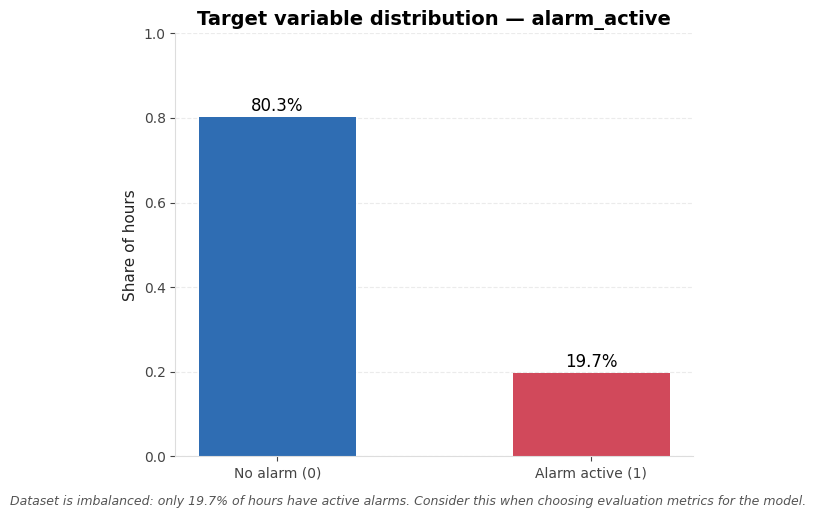

In [74]:
alarm_rate = df['alarm_active'].mean()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['No alarm (0)', 'Alarm active (1)'], [1 - alarm_rate, alarm_rate], color=[BLUE_MAIN, RED_ACCENT], width=0.5)

for bar, val in zip(bars, [1 - alarm_rate, alarm_rate]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005, f'{val:.1%}', ha='center', va='bottom', fontsize=12)

ax.set_title('Target variable distribution — alarm_active')
ax.set_ylabel('Share of hours')
ax.set_ylim(0, 1)
ax.grid(axis='y')
ax.set_axisbelow(True)

fig.text(0.5, -0.02,
         f'Dataset is imbalanced: only {alarm_rate:.1%} of hours have active alarms. '
         'Consider this when choosing evaluation metrics for the model.',
         ha='center', fontsize=9, color=TEXT_GREY, style='italic')

plt.tight_layout()
plt.savefig('target_balance.png', dpi=150, bbox_inches='tight')
plt.show()

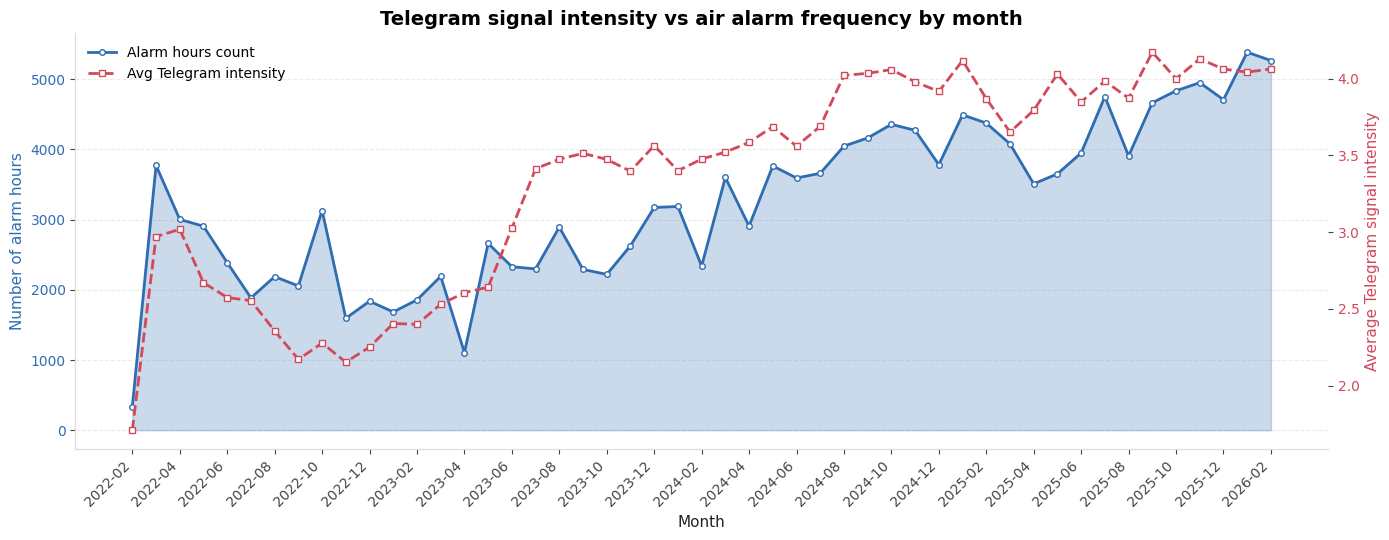

In [75]:
df['year_month'] = df['datetime_hour'].dt.to_period('M')

monthly = df.groupby('year_month').agg(
    alarm_count=('alarm_active', 'sum'),
    tg_intensity=('tg_total_intensity', 'mean')
).reset_index()

monthly = monthly.iloc[:-1]

x = np.arange(len(monthly))
x_labels = monthly['year_month'].astype(str).tolist()

fig, ax1 = plt.subplots(figsize=(14, 5.5))

ax1.fill_between(x, monthly['alarm_count'], color=BLUE_MAIN, alpha=0.25)
ax1.plot(x, monthly['alarm_count'], color=BLUE_MAIN, linewidth=2,
         marker='o', markersize=4, markerfacecolor='white', label='Alarm hours count')
ax1.set_ylabel('Number of alarm hours', color=BLUE_MAIN)
ax1.tick_params(axis='y', labelcolor=BLUE_MAIN)

ax2 = ax1.twinx()
ax2.plot(x, monthly['tg_intensity'], color=RED_ACCENT, linewidth=2,
         linestyle='--', marker='s', markersize=4, markerfacecolor='white',
         label='Avg Telegram intensity')
ax2.set_ylabel('Average Telegram signal intensity', color=RED_ACCENT)
ax2.tick_params(axis='y', labelcolor=RED_ACCENT)

tick_idx = np.arange(0, len(x_labels), 2)
ax1.set_xticks(tick_idx)
ax1.set_xticklabels([x_labels[i] for i in tick_idx], rotation=45, ha='right')

ax1.set_title('Telegram signal intensity vs air alarm frequency by month')
ax1.set_xlabel('Month')
ax1.grid(axis='y')
ax1.set_axisbelow(True)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc='upper left')

plt.tight_layout()
plt.savefig('tg_vs_alarms.png', dpi=150, bbox_inches='tight')
plt.show()

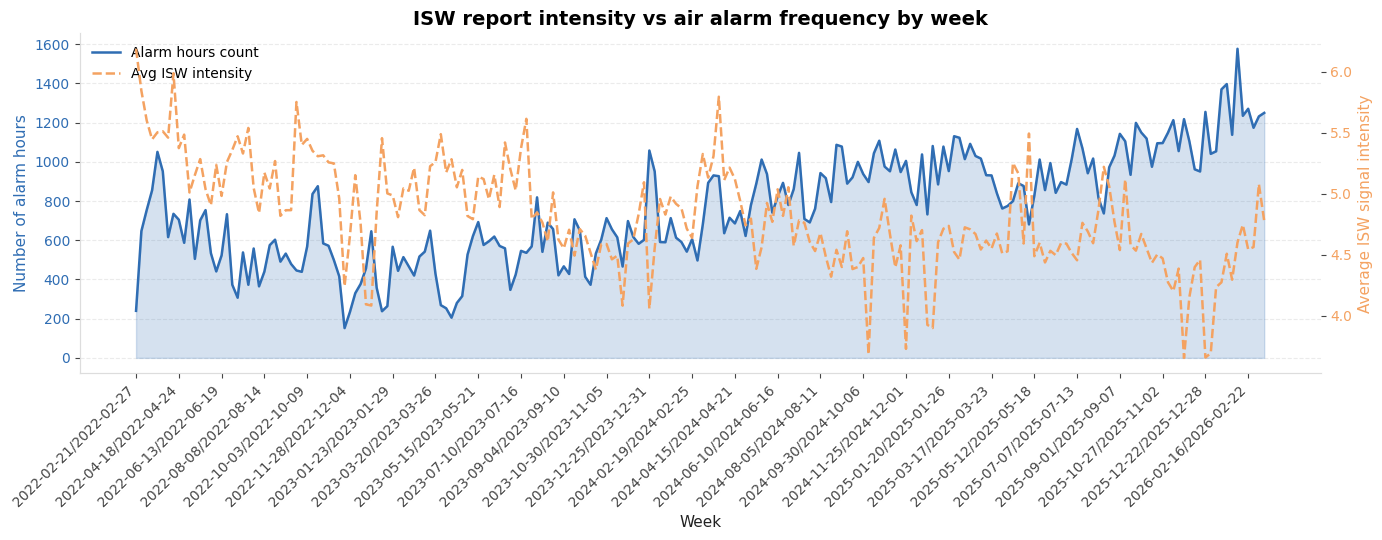

In [76]:
df['year_week'] = df['datetime_hour'].dt.to_period('W')

weekly = df.groupby('year_week').agg(
    alarm_count=('alarm_active', 'sum'),
    isw_intensity=('isw_total_intensity', 'mean')
).reset_index()

weekly = weekly.iloc[:-1]
x = np.arange(len(weekly))
x_labels = weekly['year_week'].astype(str).tolist()

fig, ax1 = plt.subplots(figsize=(14, 5.5))

ax1.fill_between(x, weekly['alarm_count'], color=BLUE_MAIN, alpha=0.2)
ax1.plot(x, weekly['alarm_count'], color=BLUE_MAIN, linewidth=1.8,
         label='Alarm hours count')
ax1.set_ylabel('Number of alarm hours', color=BLUE_MAIN)
ax1.tick_params(axis='y', labelcolor=BLUE_MAIN)

ax2 = ax1.twinx()
ax2.plot(x, weekly['isw_intensity'], color=GOLD, linewidth=1.8,
         linestyle='--', label='Avg ISW intensity')
ax2.set_ylabel('Average ISW signal intensity', color=GOLD)
ax2.tick_params(axis='y', labelcolor=GOLD)

tick_idx = np.arange(0, len(x_labels), 8)
ax1.set_xticks(tick_idx)
ax1.set_xticklabels([x_labels[i] for i in tick_idx], rotation=45, ha='right')

ax1.set_title('ISW report intensity vs air alarm frequency by week')
ax1.set_xlabel('Week')
ax1.grid(axis='y')
ax1.set_axisbelow(True)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc='upper left')

plt.tight_layout()
plt.savefig('isw_vs_alarms.png', dpi=150, bbox_inches='tight')
plt.show()

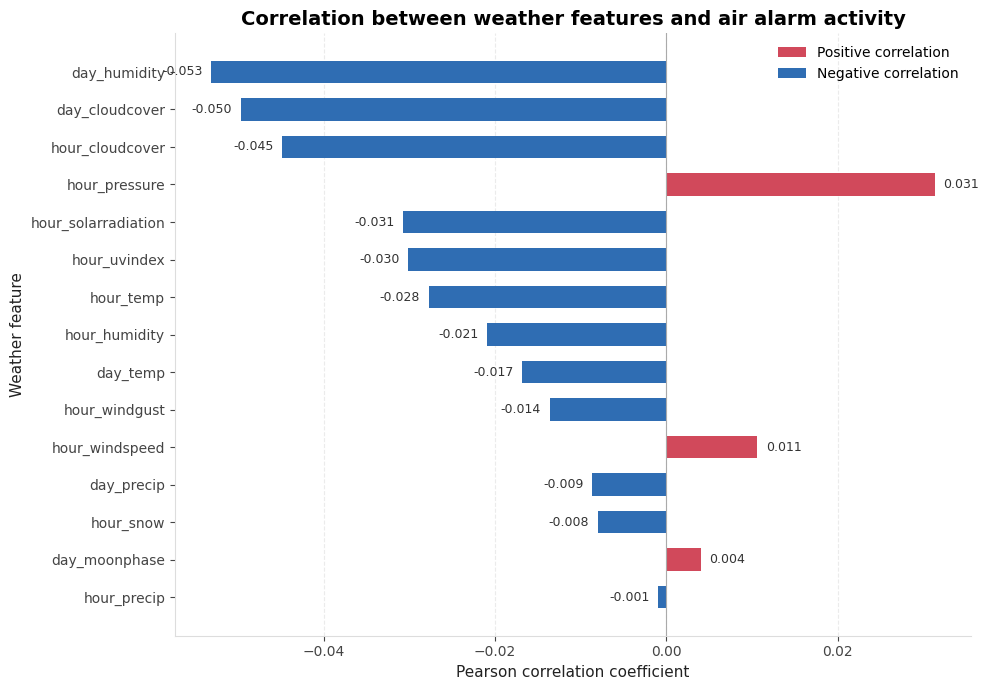

In [77]:
weather_cols = ['hour_temp', 'hour_humidity', 'hour_precip', 'hour_windspeed', 'hour_windgust', 'hour_pressure', 'hour_cloudcover', 
                'hour_solarradiation', 'hour_uvindex', 'hour_snow', 'day_temp', 'day_humidity', 'day_precip', 'day_cloudcover', 'day_moonphase']

corr = df[weather_cols + ['alarm_active']].corr()['alarm_active'].drop('alarm_active')
corr_sorted = corr.abs().sort_values(ascending=True)
colors = [RED_ACCENT if v > 0 else BLUE_MAIN for v in corr[corr_sorted.index]]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(corr_sorted.index, corr[corr_sorted.index], color=colors, height=0.6)

ax.axvline(0, color='#AAAAAA', linewidth=0.8)

for bar, val in zip(bars, corr[corr_sorted.index]):
    ax.text(
        val + (0.001 if val >= 0 else -0.001),
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9,
        color='#333333'
    )

ax.set_title('Correlation between weather features and air alarm activity')
ax.set_xlabel('Pearson correlation coefficient')
ax.set_ylabel('Weather feature')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=RED_ACCENT, label='Positive correlation'), Patch(facecolor=BLUE_MAIN, label='Negative correlation')]
ax.legend(handles=legend_elements, frameon=False)
ax.grid(axis='x')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('weather_alarm_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

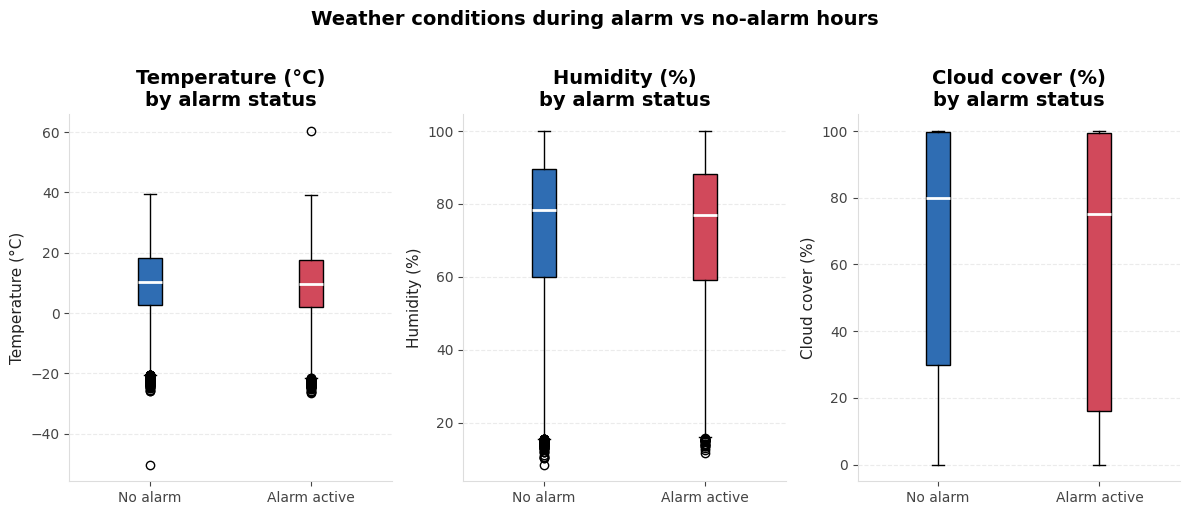

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

for ax, col, label in zip(axes,
    ['hour_temp', 'hour_humidity', 'hour_cloudcover'],
    ['Temperature (°C)', 'Humidity (%)', 'Cloud cover (%)']):

    data = [df[df['alarm_active']==0][col].dropna(),
            df[df['alarm_active']==1][col].dropna()]

    bp = ax.boxplot(data, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2))

    bp['boxes'][0].set_facecolor(BLUE_MAIN)
    bp['boxes'][1].set_facecolor(RED_ACCENT)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['No alarm', 'Alarm active'])
    ax.set_title(f'{label}\nby alarm status')
    ax.set_ylabel(label)
    ax.grid(axis='y')
    ax.set_axisbelow(True)

plt.suptitle('Weather conditions during alarm vs no-alarm hours',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('weather_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

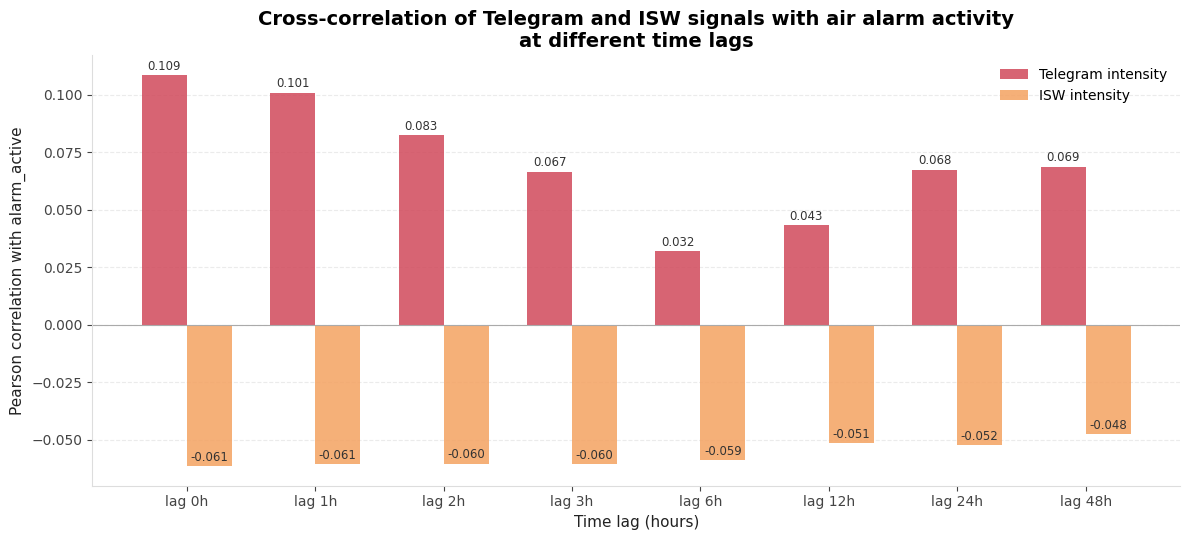

In [79]:
lags = [0, 1, 2, 3, 6, 12, 24, 48]

tg_corrs = []
isw_corrs = []

for lag in lags:
    tg_corrs.append(df['alarm_active'].corr(df['tg_total_intensity'].shift(lag)))
    isw_corrs.append(df['alarm_active'].corr(df['isw_total_intensity'].shift(lag)))

x = np.arange(len(lags))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5.5))

bars1 = ax.bar(x - width/2, tg_corrs, width, label='Telegram intensity', color=RED_ACCENT, alpha=0.85)
bars2 = ax.bar(x + width/2, isw_corrs, width, label='ISW intensity', color=GOLD, alpha=0.85)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.001, f'{height:.3f}', ha='center', va='bottom', fontsize=8.5, color='#333333')

ax.set_xticks(x)
ax.set_xticklabels([f'lag {l}h' for l in lags])
ax.axhline(0, color='#AAAAAA', linewidth=0.8)
ax.set_title('Cross-correlation of Telegram and ISW signals with air alarm activity\nat different time lags')
ax.set_xlabel('Time lag (hours)')
ax.set_ylabel('Pearson correlation with alarm_active')
ax.legend(frameon=False)
ax.grid(axis='y')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('cross_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

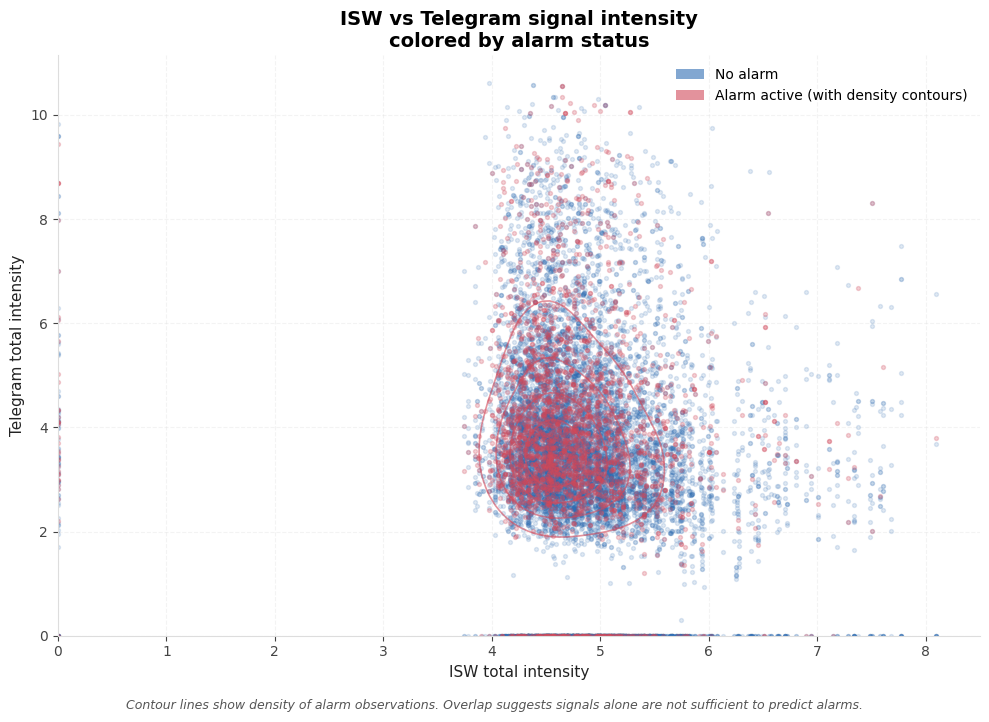

In [80]:
sample = df.sample(n=15000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 7))

no_alarm = sample[sample['alarm_active'] == 0]
alarm = sample[sample['alarm_active'] == 1]

ax.scatter(no_alarm['isw_total_intensity'], no_alarm['tg_total_intensity'], c=BLUE_MAIN, alpha=0.15, s=8, label='No alarm')
ax.scatter(alarm['isw_total_intensity'], alarm['tg_total_intensity'], c=RED_ACCENT, alpha=0.25, s=8, label='Alarm active')

from scipy.stats import gaussian_kde

xy = np.vstack([alarm['isw_total_intensity'], alarm['tg_total_intensity']])
kde = gaussian_kde(xy, bw_method=0.3)
xmin, xmax = alarm['isw_total_intensity'].quantile([0.01, 0.99])
ymin, ymax = alarm['tg_total_intensity'].quantile([0.01, 0.99])

xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
z = kde(positions).reshape(xx.shape)

ax.contour(xx, yy, z, levels=5, colors=RED_ACCENT, alpha=0.6, linewidths=1.2)

ax.set_title('ISW vs Telegram signal intensity\ncolored by alarm status')
ax.set_xlabel('ISW total intensity')
ax.set_ylabel('Telegram total intensity')

legend_elements = [
    mpatches.Patch(facecolor=BLUE_MAIN, alpha=0.6, label='No alarm'),
    mpatches.Patch(facecolor=RED_ACCENT, alpha=0.6, label='Alarm active (with density contours)')
]
ax.legend(handles=legend_elements, frameon=False)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)

fig.text(0.5, -0.02,
         'Contour lines show density of alarm observations. Overlap suggests signals alone are not sufficient to predict alarms.',
         ha='center', fontsize=9, color=TEXT_GREY, style='italic')

plt.tight_layout()
plt.savefig('isw_tg_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

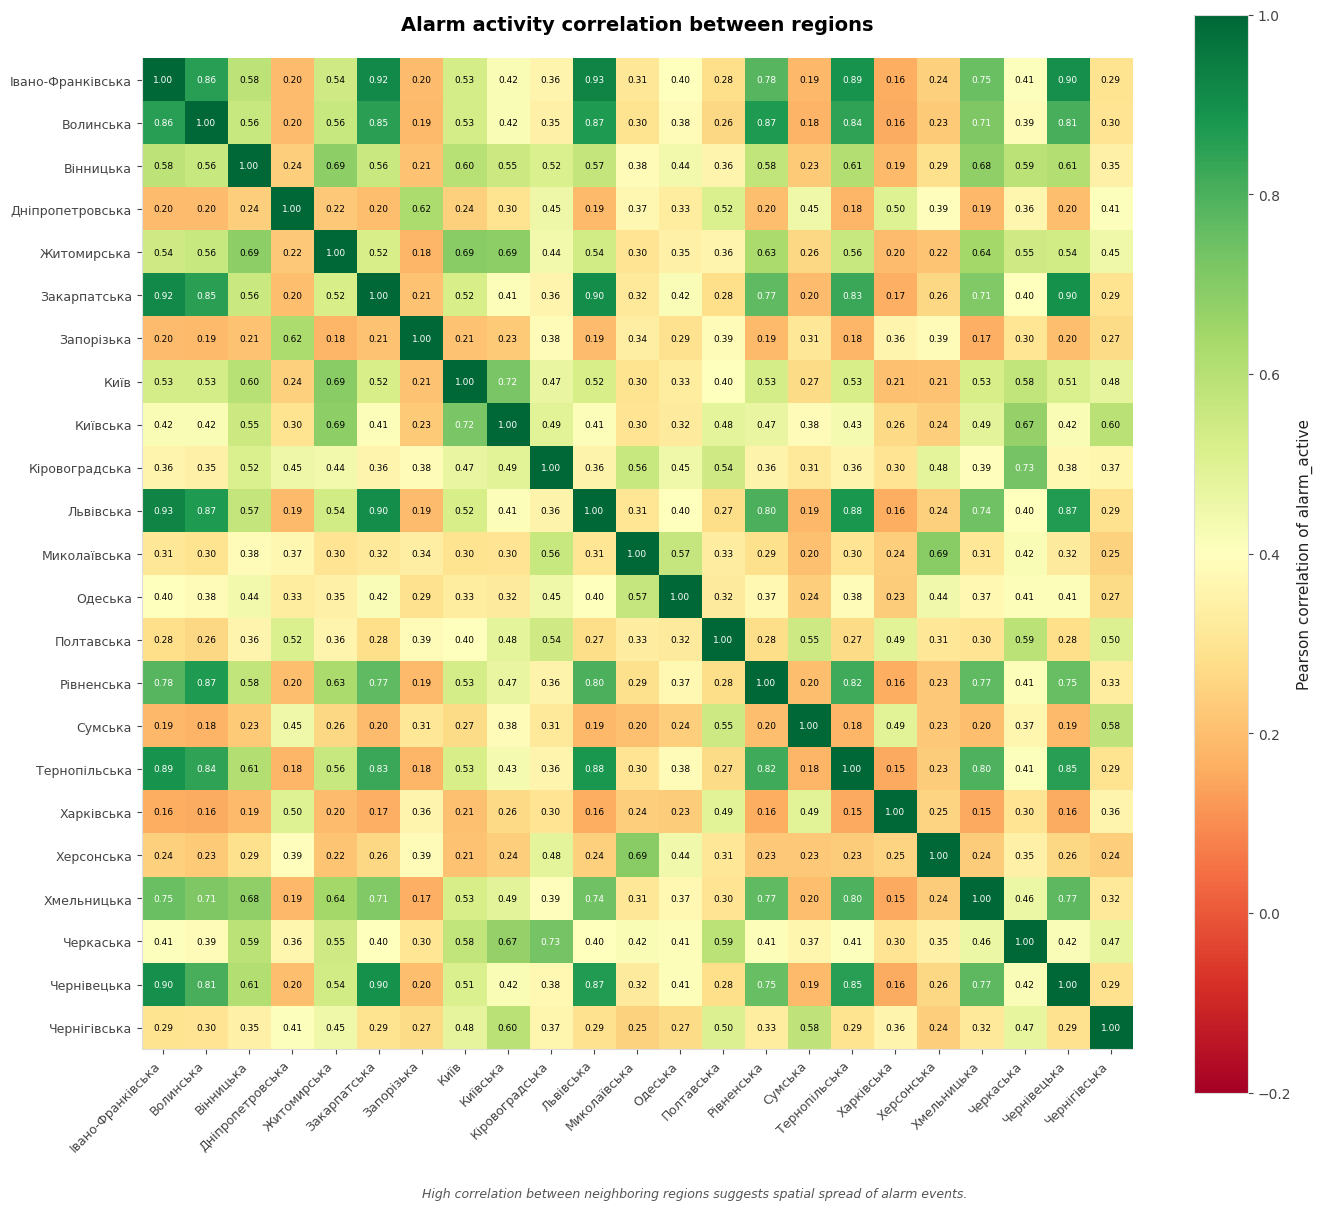

In [81]:
alarm_pivot = df.pivot_table(
    index='datetime_hour', 
    columns='region_key', 
    values='alarm_active'
)

region_corr = alarm_pivot.corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(region_corr.values, cmap='RdYlGn', vmin=-0.2, vmax=1)

ax.set_xticks(range(len(region_corr.columns)))
ax.set_yticks(range(len(region_corr.columns)))
ax.set_xticklabels(region_corr.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(region_corr.columns, fontsize=9)

for i in range(len(region_corr)):
    for j in range(len(region_corr)):
        val = region_corr.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6.5,
                color='black' if val < 0.7 else 'white')

plt.colorbar(im, ax=ax, label='Pearson correlation of alarm_active')
ax.set_title('Alarm activity correlation between regions', pad=20)
fig.text(0.5, -0.01,
         'High correlation between neighboring regions suggests spatial spread of alarm events.',
         ha='center', fontsize=9, color=TEXT_GREY, style='italic')
plt.tight_layout()
plt.savefig('region_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [82]:
url = "https://raw.githubusercontent.com/EugeneBorshch/ukraine_geojson/master/UA_FULL_Ukraine.geojson"
geo = requests.get(url).json()

for i, feature in enumerate(geo['features']):
    feature['id'] = str(i)

df['datetime_hour'] = pd.to_datetime(df['datetime_hour'])
df['year_month'] = df['datetime_hour'].dt.to_period('M').astype(str)

monthly = (df.groupby(['region_key', 'year_month'])['alarm_active'].mean().reset_index())

months = sorted(monthly['year_month'].unique())
timestamps = [str(int(pd.Timestamp(m).timestamp())) for m in months]

colormap = cm.LinearColormap(['#ffffcc', '#fd8d3c', '#800026'], vmin=0, vmax=1, caption='Average Alarm Rate')

styledict = {}

for i, feature in enumerate(geo['features']):
    iso = feature['properties'].get('iso3166-2', '')
    name_uk = feature['properties'].get('name:uk', '')
    
    region_name = name_uk.replace(' область', '').replace('Автономна Республіка ', '').strip()
    if region_name == "місто Київ": region_name = "Київ"
    if region_name == "місто Севастополь": region_name = "Севастополь"
    
    feature_id = feature['id']
    styledict[feature_id] = {}
    
    for month, ts in zip(months, timestamps):
        val = monthly[(monthly['region_key'] == region_name) & (monthly['year_month'] == month)]['alarm_active']
        rate = float(val.iloc[0]) if not val.empty else 0.0
        styledict[feature_id][ts] = {'color': colormap(rate),'opacity': 0.7}

m = folium.Map(location=[48.3, 31.1], zoom_start=6, tiles='CartoDB positron')

TimeSliderChoropleth(data=geo, styledict=styledict, ).add_to(m)

colormap.add_to(m)
m.save("map_fixed.html")
m

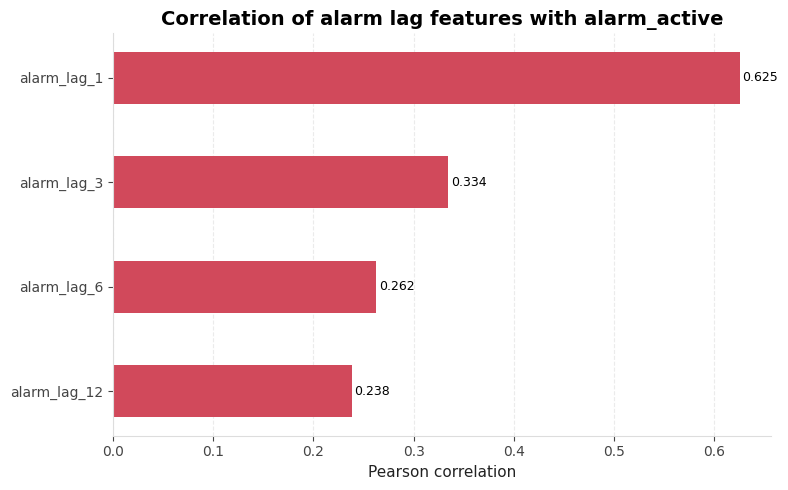

In [83]:
lag_cols = ['alarm_lag_1', 'alarm_lag_3', 'alarm_lag_6', 'alarm_lag_12']
corrs = df[lag_cols].corrwith(df['alarm_active']).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(corrs.index, corrs.values, color=RED_ACCENT, height=0.5)
for bar, val in zip(bars, corrs.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_title('Correlation of alarm lag features with alarm_active')
ax.set_xlabel('Pearson correlation')
ax.grid(axis='x')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

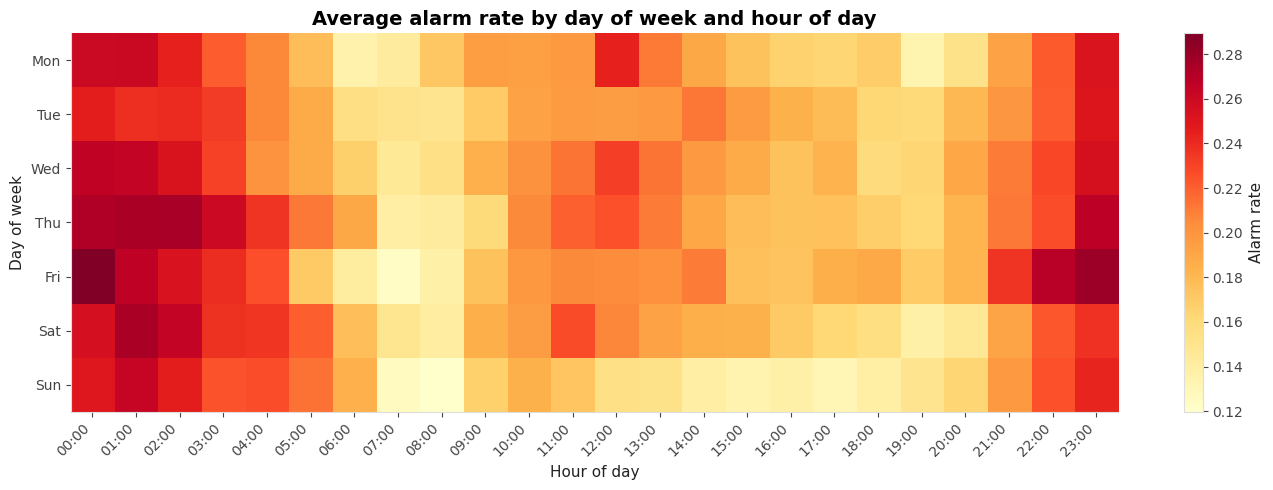

In [85]:
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

heatmap_data = (df.groupby(['day_of_week', 'hour'])['alarm_active'].mean().unstack())

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='YlOrRd')

ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
ax.set_yticks(range(7))
ax.set_yticklabels(days)

ax.set_title('Average alarm rate by day of week and hour of day')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Day of week')

plt.colorbar(im, ax=ax, label='Alarm rate')
plt.tight_layout()
plt.savefig('alarm_heatmap_weekday_hour.png', dpi=150, bbox_inches='tight')
plt.show()

## Data shift for further models training

In [86]:
df_to_train = df_final.copy()
df_to_train = df_to_train.sort_values(['region_id', 'datetime_hour'])

In [87]:
isw_cols = [c for c in df_to_train.columns if 'isw_' in c]
df_to_train[isw_cols] = df_to_train.groupby('region_id')[isw_cols].shift(24).fillna(0)

In [88]:
df_to_train.head()

,datetime_hour,region_id,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,...,isw_topic_entropy,isw_velocity_24h,isw_intensity_ema,tg_total_intensity,tg_topic_std,tg_topic_max,tg_topic_entropy,tg_velocity_3h,tg_intensity_ema_6h,tg_intensity_zscore
0,2022-02-24 00:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
1,2022-02-24 01:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
2,2022-02-24 02:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
3,2022-02-24 03:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
4,2022-02-24 04:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0


In [89]:
tg_cols = [c for c in df_to_train.columns if 'tg_' in c]
df_to_train[tg_cols] = df_to_train.groupby('region_id')[tg_cols].shift(1).fillna(0)

In [90]:
df_to_train.head()

,datetime_hour,region_id,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,...,isw_topic_entropy,isw_velocity_24h,isw_intensity_ema,tg_total_intensity,tg_topic_std,tg_topic_max,tg_topic_entropy,tg_velocity_3h,tg_intensity_ema_6h,tg_intensity_zscore
0,2022-02-24 00:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-02-24 01:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
2,2022-02-24 02:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
3,2022-02-24 03:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
4,2022-02-24 04:00:00,2,5.0,0.7,2.8,-0.3,80.5,0.3,100.0,4.17,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0


In [91]:
hour_weather_cols = [c for c in df_to_train.columns if c.startswith('hour_')]
for col in hour_weather_cols:
    if df_to_train[col].dtype == bool:
        df_to_train[col] = df_to_train.groupby('region_id')[col].shift(1).fillna(False)
    else:
        df_to_train[col] = df_to_train.groupby('region_id')[col].shift(1).fillna(0)

In [92]:
day_weather_cols = [c for c in df_to_train.columns if (c.startswith('day_') and c not in ['day_datetime', 'day_sunrise', 'day_sunset', 'day_moonphase', 'day_of_week'])]
df_to_train[day_weather_cols] = df_to_train.groupby('region_id')[day_weather_cols].shift(24).fillna(0)

In [93]:
df_to_train.isna().sum()

datetime_hour          0
region_id              0
day_tempmax            0
day_tempmin            0
day_temp               0
                      ..
tg_topic_max           0
tg_topic_entropy       0
tg_velocity_3h         0
tg_intensity_ema_6h    0
tg_intensity_zscore    0
Length: 467, dtype: int64

In [94]:
df_to_train['alarm_minutes_in_hour'] = (df_to_train.groupby('region_id')['alarm_minutes_in_hour'].shift(1).fillna(0))

In [95]:
df_to_train.head()

,datetime_hour,region_id,day_tempmax,day_tempmin,day_temp,day_dew,day_humidity,day_precip,day_precipprob,day_precipcover,...,isw_topic_entropy,isw_velocity_24h,isw_intensity_ema,tg_total_intensity,tg_topic_std,tg_topic_max,tg_topic_entropy,tg_velocity_3h,tg_intensity_ema_6h,tg_intensity_zscore
0,2022-02-24 00:00:00,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-02-24 01:00:00,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
2,2022-02-24 02:00:00,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
3,2022-02-24 03:00:00,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
4,2022-02-24 04:00:00,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0


In [96]:
print(f"Final dataset shape: {df_to_train.shape}")
print(f"Date range: {df_to_train['datetime_hour'].min()} → {df_to_train['datetime_hour'].max()}")
print(f"Regions: {df_to_train['region_id'].nunique()}")
print(f"Target balance: {df_to_train['alarm_active'].mean():.2%} positive")
print(f"NaN count: {df_to_train.isna().sum().sum()}")

Final dataset shape: (817972, 467)
Date range: 2022-02-24 00:00:00 → 2026-03-16 23:00:00
Regions: 23
Target balance: 19.74% positive
NaN count: 0


In [ ]:
df_to_train.to_parquet(output, index=False, engine="pyarrow")